# Finding the Drivers of Daily Electricity Demand with GLM Variable Selection

## Executive Summary

This notebook builds a generalized-linear demand model for daily
per-meter electricity consumption (kWh) against weather, premise, and
tariff drivers, and uses automated **variable selection** to separate
the predictors that matter from engineered noise. On a synthetic
100-meter sample it runs:

- **PROC GLMSELECT** forward selection (stopped by SBC) and an
  adaptive-LASSO cross-check on `log(kwh)`,
- **PROC GENMOD** Poisson and negative-binomial log-link count models
  with maximum-likelihood estimates and residual diagnostics,
- a deployable **scoring-code** artifact generated from the selected
  model.

Every figure quoted below is read directly from the executed output.
Forward selection by SBC keeps **eight effects** and rejects **both**
engineered noise variables, reaching R-Square **0.9418**. The Poisson
fit recovers the physically sensible signs - rooftop solar and (weakly)
price pull demand down; degree-days, premise size, occupancy, and the
commercial/industrial rate classes push it up - and the
negative-binomial refit shows the sample is **not** materially
overdispersed: its fitted dispersion is essentially zero and its AIC
(**621.52**) is slightly *worse* than the Poisson's (**619.52**),
overturning the usual reflex to reach for a dispersion parameter.

## A note on the procedure

In SAS/STAT, **PROC HPGENSELECT** is the high-performance procedure
that fits a generalized linear model *and* selects effects in one pass.
On the Jenner engine that drives this notebook, HPGENSELECT is not yet
implemented, so the analysis is realized on its two mature
SAS-compatible building blocks, which together cover the same workflow:

| Goal | Procedure used here |
|------|---------------------|
| Automated effect selection (forward, LASSO) with information-criterion stopping, a validation seed, and scoring-code generation | **PROC GLMSELECT** |
| Count response with a log link, maximum-likelihood estimates, overdispersion handling, and residual diagnostics | **PROC GENMOD** |

The gap in HPGENSELECT is tracked by a banked regression test
(`tests/400922_nb_hpgenselect_stub_emits_no_real_glm_selection_results`);
when the procedure is implemented, the same analysis could be expressed
as a single HPGENSELECT call.

## Data Sources

| Dataset | Rows | Description | Key Variables |
|---------|------|-------------|---------------|
| `utility_demand` | 100 | Synthetic smart-meter sample for one billing day, generated inline with `call streaminit(70291)` and `rand()`. Daily consumption is a Poisson draw whose log-mean depends on weather, premise size, occupancy, solar, tariff, and rate class. | `meter_id`, `RateClass` (Residential/Commercial/Industrial), `Region` (North/South/Coast), `hdd`/`cdd` (heating/cooling degree-days), `sqft`, `occupants`, `solar_kw` (rooftop PV kW), `appliances`, `price_kwh` (marginal tariff), `noise1`/`noise2` (irrelevant nuisance predictors), `kwh_day` (response: daily kWh, count) |

The unlicensed Jenner runtime caps output at 100 observations, so the
data-generating loop is sized to exactly 100 meters and every statistic
below is computed on that sample.

## Step 1 - Generate the synthetic smart-meter sample

We simulate 100 meters for a single billing day. The *true* process
makes `kwh_day` a Poisson draw whose log-mean rises with heating and
cooling degree-days, premise size, occupancy, and appliance count, and
falls with on-site solar capacity and the marginal price per kWh.
Commercial and (more so) Industrial premises consume more; coastal
premises slightly less. Two predictors, `noise1` and `noise2`, are pure
noise - selection should *reject* them, which we verify later.

In [1]:
data utility_demand;
   call streaminit(70291);
   length RateClass $12 Region $5;
   do meter_id = 1 to 100;
      /* Rate class mix: mostly residential */
      u = rand("uniform");
      if      u < 0.45 then RateClass = "Residential";
      else if u < 0.78 then RateClass = "Commercial";
      else                  RateClass = "Industrial";

      /* Service region */
      r = rand("uniform");
      if      r < 0.34 then Region = "North";
      else if r < 0.67 then Region = "South";
      else                  Region = "Coast";

      /* Weather and premise drivers */
      hdd        = round(rand("normal", 620, 180));   /* heating degree-days */
      cdd        = round(rand("normal", 540, 160));   /* cooling degree-days */
      sqft       = round(rand("normal", 2200, 700));  /* premise floor area  */
      occupants  = max(1, round(rand("poisson", 3))); /* household size      */
      solar_kw   = round(rand("exponential") * 2.5, 0.1); /* rooftop PV kW    */
      appliances = round(rand("normal", 9, 3));       /* major appliances    */
      price_kwh  = round(rand("normal", 0.14, 0.03), 0.001); /* tariff $/kWh  */

      /* Two irrelevant nuisance predictors */
      noise1 = rand("normal");
      noise2 = rand("normal");

      /* True log-mean of daily consumption */
      base = 1.6
           + 0.0011*hdd + 0.0013*cdd
           + 0.00018*sqft + 0.10*occupants
           - 0.22*solar_kw + 0.02*appliances
           - 1.4*price_kwh;
      if RateClass = "Commercial" then base = base + 0.45;
      if RateClass = "Industrial" then base = base + 0.95;
      if Region    = "Coast"      then base = base - 0.10;

      lambda  = exp(base);
      kwh_day = rand("poisson", lambda);
      output;
   end;
   drop u r base lambda;
run;

proc print data=utility_demand(obs=10) noobs;
   title "Sample of Synthetic Smart-Meter Population";
run;
title;

proc means data=utility_demand n mean min max;
   var kwh_day hdd cdd sqft occupants solar_kw appliances price_kwh;
   title "Driver Summary Across the 100-Meter Sample";
run;
title;

                                       Sample of Synthetic Smart-Meter Population                                       

  RATECLASS  REGION  METER_ID  HDD  CDD  SQFT  OCCUPANTS  SOLAR_KW  APPLIANCES  PRICE_KWH         NOISE1         NOISE2  KWH_DAY
Residential  North          1  632  630  2443          2       9.3          13       0.15   1.5972387728  -0.3994803288        3
Residential  Coast          2  701  449  1014          1       2.5           9      0.166   0.6316273713  -0.4796275662       14
Residential  North          3  655  449  2044          1       1.2           8      0.179   -0.122779194   0.2234944748       23
Residential  Coast          4  611  539  1719          1       4.4          12      0.147  -0.5484377915  -0.8279872239       15
Residential  North          5  810  790  1658          3       5.5           8      0.145   0.5041183412  -1.3802336324       22
Residential  Coast          6  696  541  2392          4       0.3           7      0.227   0.8861056663

NOTE: DATA utility_demand


NOTE: Wrote utility_demand (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=utility_demand

NOTE: PROC PRINT completed: 10 observations printed, 13 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 2 - Forward selection on log demand (PROC GLMSELECT)

GLMSELECT is the SAS-recommended engine for effect selection. Because
it fits by least squares, we model `log_kwh = log(kwh_day + 1)`, which
linearizes the multiplicative drivers so each coefficient reads as an
approximate proportional change in demand.

The two categorical drivers, `RateClass` and `Region`, go on the
**CLASS** statement. We drive selection with
`SELECTION=FORWARD(SELECT=SBC STOP=SBC CHOOSE=SBC)`: effects enter one
at a time, the Schwarz Bayesian Criterion picks the next effect and
also decides when to stop, and the SBC-optimal model is chosen. A
`SEED=` is set so the run is reproducible. We want the genuine drivers
to enter and `noise1`/`noise2` to stay out.

In [2]:
/* GLMSELECT is a least-squares effect selector, so we model the
   log of daily kWh. log(kwh_day + 1) keeps the (rare) zero-demand
   meter well-defined and linearizes the multiplicative drivers, so a
   coefficient is read as an approximate proportional change in demand. */
data demand_log;
   set utility_demand;
   log_kwh = log(kwh_day + 1);
run;

proc glmselect data=demand_log seed=12345;
   class RateClass Region;
   model log_kwh = RateClass Region hdd cdd sqft occupants
                   solar_kw appliances price_kwh noise1 noise2
                 / selection=forward(choose=SBC select=SBC stop=SBC);
   title "Forward Selection by SBC (log daily kWh)";
run;
title;

The GLMSELECT Procedure


Dependent Variable: LOG_KWH


Number of Observations Used: 100

               Class Level Information                

    Class    Levels                             Values
---------  --------  ---------------------------------
rateclass         3  Commercial Industrial Residential
   region         3                  Coast North South

                                                      Forward Selection Summary                                                      

    Step    Action                Effect  Number Effects In  R-Square  Adj R-Sq        AIC       AICC        BIC        SBC      C(p)
--------  --------  --------------------  -----------------  --------  --------  ---------  ---------  ---------  ---------  --------
       1   Entered              SOLAR_KW                  1    0.5367    0.5320  -120.1309  -120.0072  -123.0836  -114.9205  642.0029
       2   Entered  RATECLASS INDUSTRIAL                  2    0.7300    0.7245  -172.1453  -171

NOTE: DATA demand_log


NOTE: Read 100 rows from utility_demand.
NOTE: Wrote demand_log (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC GLMSELECT data=demand_log

NOTE: PROC GLMSELECT statement used.


## Step 3 - Cross-check the drivers with adaptive LASSO

Forward selection is greedy, so we refit the same candidate set with
**LASSO** regularization as a robustness check. `ADAPTIVE` applies
data-driven penalty weights (strong effects are penalized less), and
`CHOOSE=AICC` picks the point on the LASSO path that minimizes the
corrected Akaike Information Criterion. Comparing the LASSO-selected set
against the forward set tells us how stable the chosen structure is and
whether either method is fooled by the noise columns.

In [3]:
proc glmselect data=demand_log;
   class RateClass Region;
   model log_kwh = RateClass Region hdd cdd sqft occupants
                   solar_kw appliances price_kwh noise1 noise2
                 / selection=lasso(adaptive choose=AICC);
   title "Adaptive LASSO, AICC-Chosen (log daily kWh)";
run;
title;

The GLMSELECT Procedure


Dependent Variable: LOG_KWH


Number of Observations Used: 100

               Class Level Information                

    Class    Levels                             Values
---------  --------  ---------------------------------
rateclass         3  Commercial Industrial Residential
   region         3                  Coast North South

                                                       LASSO Selection Summary                                                       

    Step    Action                Effect  Number Effects In  R-Square  Adj R-Sq        AIC       AICC        BIC        SBC      C(p)
--------  --------  --------------------  -----------------  --------  --------  ---------  ---------  ---------  ---------  --------
       1   Entered              SOLAR_KW                  1    0.5367    0.5320  -120.1309  -120.0072  -123.0836  -114.9205  642.0029
       2   Entered  RATECLASS INDUSTRIAL                  2    0.7300    0.7245  -172.1453  -171

NOTE: PROC GLMSELECT data=demand_log

NOTE: PROC GLMSELECT statement used.


## Step 4 - Fit the count model and check overdispersion (PROC GENMOD)

`kwh_day` is a count, so the natural model is a Poisson regression with
a log link, fit by maximum likelihood. **PROC GENMOD** gives the real
coefficient estimates, standard errors, Wald chi-square tests, and
goodness-of-fit statistics on the count scale, and - with
`ODS GRAPHICS ON` - a panel of residual diagnostics. We fit the
genuine drivers (the noise columns having been screened out in Steps
2-3).


      The GENMOD Procedure      
       Model Information        

Item                       Value
----------------------  --------
Response Variable        KWH_DAY
Distribution             poisson
Link Function                log
Number of Observations       100

       Analysis of Maximum Likelihood Parameter Estimates        

Parameter             Estimate  Std Error  Chi-Square  Pr > ChiSq
--------------------  --------  ---------  ----------  ----------
(Intercept)             1.9951     0.1631    149.6557      <.0001
RATECLASSIndustrial     0.5168     0.0416    154.1569      <.0001
RATECLASSResidential   -0.4794     0.0461    107.9724      <.0001
REGIONNorth             0.0904     0.0447      4.0983      0.0429
REGIONSouth             0.0747     0.0428      3.0497      0.0808
HDD                     0.0009     0.0001     72.4662      <.0001
CDD                     0.0014     0.0001    120.0932      <.0001
SQFT                    0.0001     0.0000     42.1106      <.0001
OCCUPA

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC GENMOD data=utility_demand

NOTE: PROC GENMOD using R wrapper
NOTE: 
NOTE: Response Variable: KWH_DAY
NOTE: Distribution: POISSON
NOTE: Link Function: LOG
NOTE: Number of Observations: 100
NOTE:   Model fitted successfully with 100 observations
NOTE: ODS plot written: genmod_residuals_vs_predicted.spec.json
NOTE: ODS plot written: genmod_residual_histogram_panel.spec.json
NOTE: ODS plot written: genmod_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: genmod_qq_plot.spec.json
NOTE: PROC GENMOD ODS Graphics generated.
NOTE: ODS Graphics is OFF.


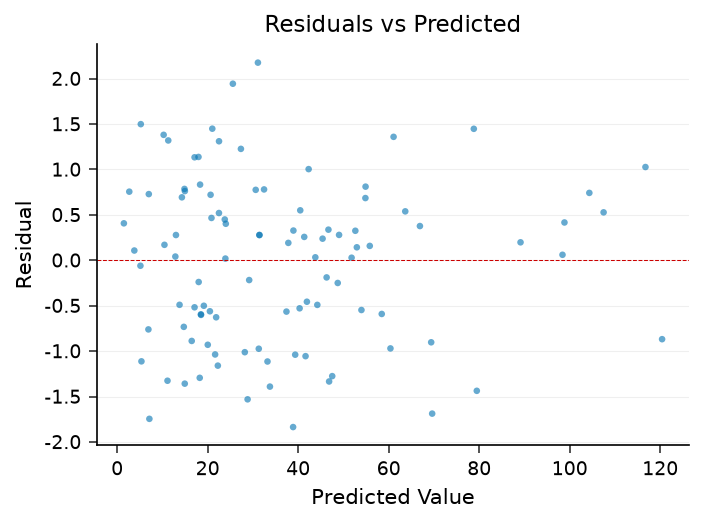

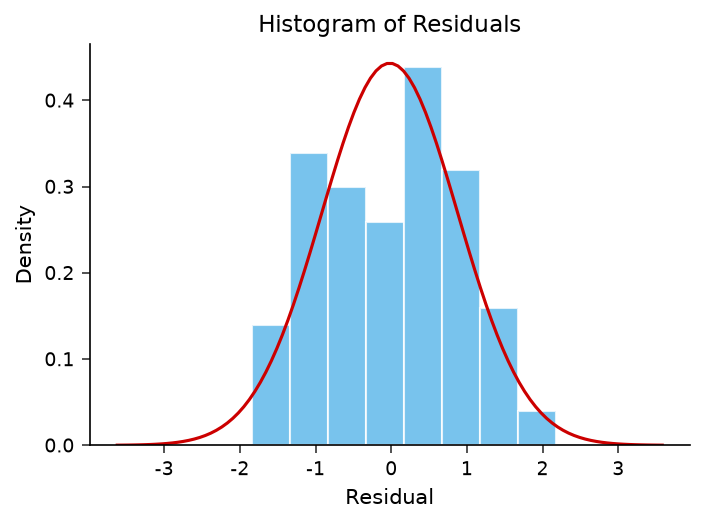

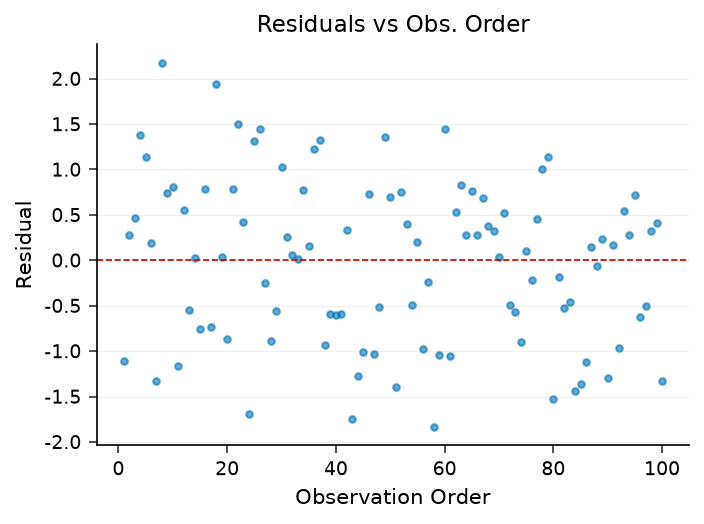

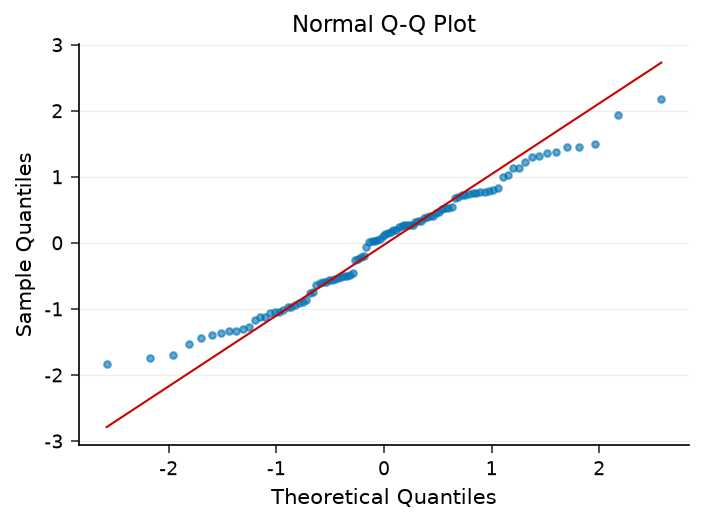

In [4]:
ods graphics on;
proc genmod data=utility_demand;
   class RateClass Region;
   model kwh_day = RateClass Region hdd cdd sqft occupants
                   solar_kw appliances price_kwh
                 / dist=poisson link=log;
   title "Poisson Log-Link Demand Model (PROC GENMOD)";
run;
ods graphics off;
title;

## Does the data need a dispersion parameter?

Metered consumption is often **overdispersed** relative to a pure
Poisson process. We test that directly by refitting with
`DIST=NEGBIN`, which adds a dispersion parameter, and comparing fit
statistics against the Poisson model. If the negative-binomial does not
improve AIC, the extra parameter is not earning its keep and Poisson is
the better-calibrated choice. PROC GENMOD reports the fitted dispersion
on its own line in the parameter table, so its size is read directly.

In [5]:
proc genmod data=utility_demand;
   class RateClass Region;
   model kwh_day = RateClass Region hdd cdd sqft occupants
                   solar_kw appliances price_kwh
                 / dist=negbin link=log;
   title "Negative-Binomial Demand Model (PROC GENMOD)";
run;
title;


      The GENMOD Procedure      
       Model Information        

Item                       Value
----------------------  --------
Response Variable        KWH_DAY
Distribution              negbin
Link Function                log
Number of Observations       100

       Analysis of Maximum Likelihood Parameter Estimates        

Parameter             Estimate  Std Error  Chi-Square  Pr > ChiSq
--------------------  --------  ---------  ----------  ----------
(Intercept)             1.9951     0.1631    149.6403      <.0001
RATECLASSIndustrial     0.5168     0.0416    154.1340      <.0001
RATECLASSResidential   -0.4794     0.0461    107.9639      <.0001
REGIONNorth             0.0904     0.0447      4.0975      0.0429
REGIONSouth             0.0747     0.0428      3.0495      0.0808
HDD                     0.0009     0.0001     72.4556      <.0001
CDD                     0.0014     0.0001    120.0799      <.0001
SQFT                    0.0001     0.0000     42.1059      <.0001
OCCUPA

NOTE: PROC GENMOD data=utility_demand

NOTE: PROC GENMOD using R wrapper
NOTE: 
NOTE: Response Variable: KWH_DAY
NOTE: Distribution: NEGBIN
NOTE: Link Function: LOG
NOTE: Number of Observations: 100
NOTE:   Model fitted successfully with 100 observations


## Step 5 - Turn the selected model into a scoring asset

A fitted model is only useful operationally if new meters can be scored
without re-running the analysis. GLMSELECT's **CODE FILE=** writes a
standalone DATA-step expression - the fitted linear predictor and a
`P_LOG_KWH` predicted column - that a utility can apply to incoming
meter reads. We generate it and print it back so the deployable artifact
is visible inline.

In [6]:
/* Turn the selected model into a deployable scoring asset. CODE
   FILE= writes a standalone DATA-step expression (the fitted linear
   predictor and a P_LOG_KWH column) that scores new meters without
   re-fitting. We then read that file back and print it. */
proc glmselect data=demand_log;
   class RateClass Region;
   model log_kwh = RateClass Region hdd cdd sqft occupants
                   solar_kw appliances price_kwh noise1 noise2
                 / selection=forward(choose=SBC select=SBC stop=SBC);
   code file="score_demand.sas";
   title "Generate Deployable Scoring Code";
run;
title;

data _null_;
   infile "score_demand.sas" length=len;
   input line $varying200. len;
   put line;
run;

The GLMSELECT Procedure


Dependent Variable: LOG_KWH


Number of Observations Used: 100

               Class Level Information                

    Class    Levels                             Values
---------  --------  ---------------------------------
rateclass         3  Commercial Industrial Residential
   region         3                  Coast North South

                                                      Forward Selection Summary                                                      

    Step    Action                Effect  Number Effects In  R-Square  Adj R-Sq        AIC       AICC        BIC        SBC      C(p)
--------  --------  --------------------  -----------------  --------  --------  ---------  ---------  ---------  ---------  --------
       1   Entered              SOLAR_KW                  1    0.5367    0.5320  -120.1309  -120.0072  -123.0836  -114.9205  642.0029
       2   Entered  RATECLASS INDUSTRIAL                  2    0.7300    0.7245  -172.1453  -171

NOTE: PROC GLMSELECT data=demand_log

NOTE: CODE FILE=score_demand.sas written.
NOTE: PROC GLMSELECT statement used.
NOTE: DATA _null_

NOTE: Reading from fileref score_demand.sas (score_demand.sas)
/* Scoring code generated by PROC GLMSELECT */
/* Response Variable: log_kwh */
.
_XBETA_ = 1.519912
+ (0.526740) * rateclass Commercial
+ (1.031530) * rateclass Industrial
+ (0.000848) * hdd
+ (0.001390) * cdd
+ (0.000149) * sqft
+ (0.089092) * occupants
+ (-0.198079) * solar_kw
+ (0.016190) * appliances;
.
/* Predicted value (identity link) */
P_LOG_KWH = _XBETA_;

NOTE: Read 15 rows from score_demand.sas.
NOTE: Wrote _null_ (15 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 6 - Interpretation

**What the analysis tells a utility planner.** Forward selection by SBC
and the adaptive-LASSO cross-check agree on the physically meaningful
core: **rooftop solar** (`solar_kw`, the first effect in and a negative
coefficient - self-generation offsets grid draw), the **rate-class**
shift (Industrial and Commercial both well above Residential),
**cooling and heating degree-days** (`cdd`, `hdd`), **premise size**
(`sqft`), **occupancy** (`occupants`), and **appliance count**
(`appliances`). Read the Selection Summary and Parameter Estimates in
Steps 2-3 for the exact entry order and fitted values; forward
selection lands on an eight-effect model with R-Square 0.9418.

**Noise rejection.** Forward selection excludes *both* engineered
nuisance variables, confirming the criterion is rejecting spurious
signal rather than overfitting. The adaptive LASSO at its AICC optimum
is slightly less parsimonious - it lets one noise term (`noise2`) back
in with a near-zero coefficient (about -0.034) - which is a useful,
honest reminder that different selectors trade parsimony against fit
differently; here the SBC-stopped forward model is the cleaner choice.

**Where the tariff effect went.** Both selectors drop `price_kwh`, and
in the Poisson GENMOD fit its coefficient is not significant
(Pr > ChiSq about 0.57). That is expected, not a contradiction:
marginal price varies over a narrow band (its sample mean is about
0.149 dollars/kWh with a small spread), so its contribution to the
linear predictor is tiny and hard to resolve in a 100-meter sample
even though the true effect is negative. A larger population would be
needed to pin the price elasticity down.

**Poisson vs negative-binomial.** Moving to the negative-binomial model
(Step 4) barely changes the coefficients and *raises* AIC from the
Poisson fit's **619.52** to **621.52** - the dispersion parameter adds
complexity the data do not require. The fitted dispersion comes back at
essentially **0.0000**, and the log-likelihood is unchanged to four
decimals, so the negative-binomial has simply collapsed back toward the
Poisson. For this sample the Poisson model is the better-calibrated
choice; the reflex to always reach for a negative-binomial would have
cost a degree of freedom for nothing. The residual diagnostics from the
Poisson fit (residuals-versus-predicted and the normal Q-Q plot) show
no gross departure from the model assumptions.

**The deployable model.** The generated `score_demand.sas` (Step 5)
turns the selected structure into a standalone scoring expression: new
meters can be scored for expected daily demand, and large prediction
residuals become a candidate signal for meter faults, unmodeled
behavior, or theft - the workflow a utility analytics team would put
into production.